# 第二部分：机器学习基础

本章使用 **scikit-learn** 作为主要工具，覆盖经典机器学习算法的核心概念与实践。

## 目录

| 章节 | 内容 |
|------|------|
| **2.1 机器学习概述** | 问题类型、学习范式、基本流程 |
| **2.2 数据预处理** | 缺失值处理、特征缩放、编码、Pipeline、PCA 降维 |
| **2.3 线性模型** | 线性回归、逻辑回归、正则化（L1/L2） |
| **2.4 树模型** | 决策树、随机森林、梯度提升（XGBoost） |
| **2.5 支持向量机** | 硬间隔、软间隔、核函数 |
| **2.6 聚类算法** | K-Means、DBSCAN |
| **2.7 模型评估** | 交叉验证、偏差-方差权衡、分类/回归指标 |

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification, make_regression, make_blobs, make_moons
from sklearn.model_selection import train_test_split

matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
print('环境就绪')

环境就绪


## 2.1 机器学习概述

### 什么是机器学习

机器学习是让计算机**从数据中自动找规律**，而不是手动编写规则。

传统编程：`数据 + 规则 → 答案`  
机器学习：`数据 + 答案 → 规则（模型）`

### 三种学习范式

| 类型 | 有无标签 | 目标 | 典型算法 |
|------|----------|------|----------|
| **监督学习** | 有 | 预测输出 y | 线性回归、逻辑回归、随机森林 |
| **无监督学习** | 无 | 发现数据结构 | K-Means、PCA、自编码器 |
| **强化学习** | 奖励信号 | 学习最优策略 | Q-Learning、PPO |

### 监督学习的两类问题

- **回归（Regression）**：预测连续值（房价、股价、温度）
- **分类（Classification）**：预测离散类别（垃圾邮件/正常、猫/狗/鸟）

### 标准 ML 工作流

```
原始数据 → 数据预处理 → 特征工程 → 模型选择 → 训练 → 评估 → 调参 → 部署
```

**过拟合 vs 欠拟合**：模型在训练集表现好但测试集差 = 过拟合；训练集和测试集都差 = 欠拟合。解决方法分别是正则化/更多数据，和更复杂的模型。

=== Iris 数据集 ===
特征数量: 4  (['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'])
样本数量: 150
类别: ['setosa' 'versicolor' 'virginica']

前 3 行:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]

训练集: 120 样本，测试集: 30 样本

测试集准确率: 0.933


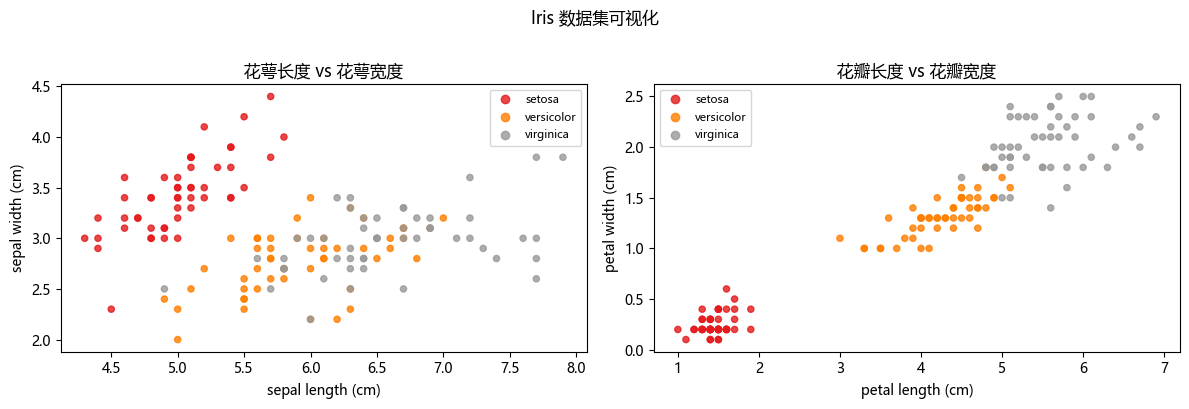

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ── 标准 sklearn 工作流演示（Iris 数据集）────────────────────
iris = load_iris()
X, y = iris.data, iris.target

print('=== Iris 数据集 ===')
print(f'特征数量: {X.shape[1]}  ({iris.feature_names})')
print(f'样本数量: {X.shape[0]}')
print(f'类别: {iris.target_names}')
print(f'\n前 3 行:\n{X[:3]}')

# 1. 划分训练集/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\n训练集: {X_train.shape[0]} 样本，测试集: {X_test.shape[0]} 样本')

# 2. 特征缩放
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit + transform
X_test_sc  = scaler.transform(X_test)       # 只 transform，用训练集的均值/方差

# 3. 训练模型
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sc, y_train)

# 4. 预测 & 评估
y_pred = model.predict(X_test_sc)
print(f'\n测试集准确率: {accuracy_score(y_test, y_pred):.3f}')

# 5. 可视化前两个特征的决策边界
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (f1, f2, title) in zip(axes, [
    (0, 1, '花萼长度 vs 花萼宽度'),
    (2, 3, '花瓣长度 vs 花瓣宽度'),
]):
    scatter = ax.scatter(X[:, f1], X[:, f2], c=y, cmap='Set1', s=20, alpha=0.8)
    ax.set_xlabel(iris.feature_names[f1])
    ax.set_ylabel(iris.feature_names[f2])
    ax.set_title(title)
    ax.legend(handles=scatter.legend_elements()[0],
               labels=list(iris.target_names), fontsize=8)

plt.suptitle('Iris 数据集可视化', y=1.01)
plt.tight_layout()
plt.show()

## 2.2 数据预处理

真实数据往往有缺失值、量纲不一致、类别型特征等问题，直接喂给模型会影响效果。预处理是 ML 流程中最耗时也最重要的环节。

### 缺失值处理

- **删除**：缺失比例高的列/行
- **填充**：均值/中位数（数值）、众数/固定值（类别）
- **预测填充**：用其他特征训练模型来预测缺失值

### 特征缩放

许多算法（KNN、SVM、神经网络、线性回归+正则化）对特征量纲敏感，需要缩放。树模型不需要缩放。

| 方法 | 公式 | 特点 |
|------|------|------|
| **StandardScaler** | (x - μ) / σ | 均值0方差1，适合大多数场景 |
| **MinMaxScaler** | (x - min) / (max - min) | 压缩到 [0,1]，对异常值敏感 |
| **RobustScaler** | (x - 中位数) / IQR | 对异常值不敏感 |

### 类别特征编码

- **LabelEncoder**：整数编码（0,1,2…），适合有序类别或树模型
- **OneHotEncoder**：独热编码，适合无序类别 + 线性模型

### sklearn Pipeline

将预处理和模型串联成一个对象，避免数据泄露，方便复用。

### PCA（主成分分析）降维

PCA 是一种**无监督降维**方法，将高维数据投影到方差最大的方向上，用更少的维度保留最多信息。

**核心思路**：
1. 对数据做**中心化**（减去列均值，消除背景偏移）
2. 计算协方差矩阵，找出方差最大的方向（主成分）
3. 按解释方差比从大到小排列，取前 k 个方向投影

**典型用途**：
- 高维数据可视化（压缩到 2D/3D 画图）
- 消除冗余特征，减少计算量
- 去除噪声（低方差方向往往是噪声）

**主成分数量怎么选**？看**累计解释方差比**，通常选覆盖 80%~95% 方差所需的最少主成分数。

**与 SVD 的关系**：`sklearn.PCA` 内部是对**中心化（减去列均值）**后的数据矩阵做 SVD，两者数学等价，PCA 额外提供统计解释（解释方差比）。特征量纲不同时（如身高+体重+年龄）才需要额外加 `StandardScaler`。

每个词的平均词频（PCA 要先减去这部分背景值）：
  模型    均值 = 5.4
  训练    均值 = 5.5
  数据    均值 = 5.0
  神经网络  均值 = 5.0
  文本    均值 = 3.4
  图像    均值 = 3.6
  词向量   均值 = 3.0
  奖励    均值 = 3.2
  策略    均值 = 3.2
  分类    均值 = 5.2

sklearn PCA 与手动中心化 SVD 坐标对比（前 3 篇文章）：
  文章                        手动中心化 SVD            sklearn PCA
  监督学习入门               (-2.68, +0.54)         (-2.68, +0.54)
  决策树原理                (-2.80, +1.05)         (-2.80, +1.05)
  随机森林调参               (-1.18, +0.85)         (-1.18, +0.85)
  → 数值相同（轴方向可能镜像，但空间结构完全一致）


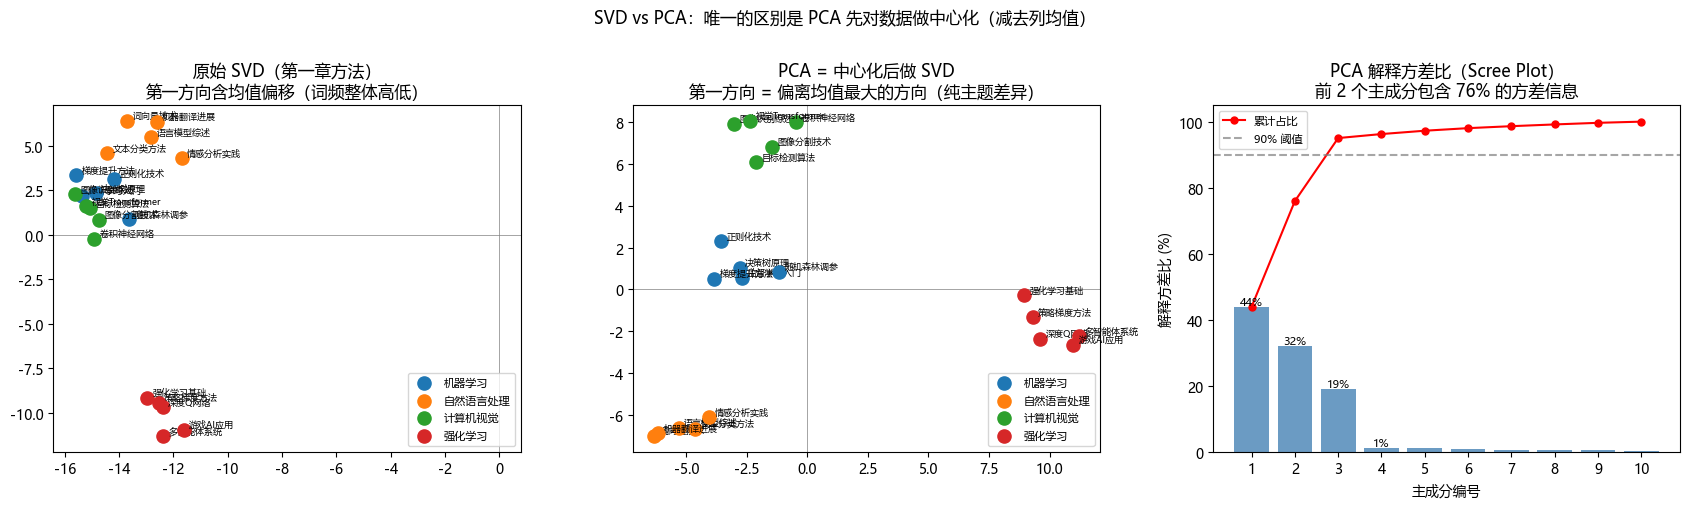


=== 为什么有了 SVD 还需要 PCA？ ===

  SVD（原始矩阵）:
    第一奇异方向由词频绝对量主导，含均值偏移（文章整体词频高低）
    适合：矩阵结构分解，如推荐系统的用户-商品矩阵

  PCA = 先减均值，再做 SVD:
    消除「背景词频」，只保留「偏差」：这篇文章比平均多用了哪些词？
    第一主成分 = 区分文章主题差异最显著的方向
    适合：数据分析、可视化、特征降维

  关系总结:
    np.linalg.svd(A)              → 纯数学工具，直接分解
    sklearn.PCA.fit_transform(A)  → 自动中心化 + SVD + 解释方差比

  何时还需要 StandardScaler（除以标准差）？
    特征量纲不同时：身高(cm)、体重(kg)、年龄(岁) 方差差异巨大
    需要 StandardScaler → PCA，否则方差大的特征会主导结果
    本例词频量纲一致（都是次数），只中心化即可，无需 StandardScaler


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ── 与第一章完全相同的文章词频数据 ───────────────────────────
words = ["模型","训练","数据","神经网络","文本","图像","词向量","奖励","策略","分类"]
articles = [
    "监督学习入门","决策树原理","随机森林调参","梯度提升方法","正则化技术",
    "词向量技术",  "语言模型综述","文本分类方法","机器翻译进展","情感分析实践",
    "图像识别综述","卷积神经网络","目标检测算法","图像分割技术","视觉Transformer",
    "强化学习基础","策略梯度方法","深度Q网络",  "多智能体系统","游戏AI应用",
]
topic_labels = ['机器学习']*5 + ['自然语言处理']*5 + ['计算机视觉']*5 + ['强化学习']*5
colors       = ['C0']*5 + ['C1']*5 + ['C2']*5 + ['C3']*5

base = np.array([
    [8, 6, 7, 2, 1, 1, 0, 0, 0, 5],
    [4, 3, 3, 2, 8, 1, 7, 0, 0, 6],
    [3, 5, 4, 7, 1, 9, 0, 0, 0, 4],
    [2, 4, 2, 5, 0, 0, 0, 8, 9, 2],
], dtype=float)
np.random.seed(42)
A = np.vstack([base[i // 5] + np.random.randint(0, 3, size=10) for i in range(20)])

# ── 核心区别：PCA 先对数据做中心化 ───────────────────────────
col_mean   = A.mean(axis=0)    # 每个词在所有文章的平均词频 (10,)
A_centered = A - col_mean      # 减均值后：体现"比平均多/少用了哪些词"

print("每个词的平均词频（PCA 要先减去这部分背景值）：")
for w, m in zip(words, col_mean):
    print(f"  {w:<5} 均值 = {m:.1f}")

# ── 方法一：SVD 直接作用于原始矩阵（第一章做法）────────────
_, _, Vt_raw = np.linalg.svd(A, full_matrices=False)
coords_raw   = A @ Vt_raw[:2].T            # shape: (20, 2)

# ── 方法二：手动中心化后做 SVD（= PCA 的数学本质）───────────
_, _, Vt_cen = np.linalg.svd(A_centered, full_matrices=False)
coords_cen   = A_centered @ Vt_cen[:2].T  # shape: (20, 2)

# ── 方法三：sklearn PCA（内部自动中心化 + SVD）───────────────
pca2        = PCA(n_components=2)
coords_pca  = pca2.fit_transform(A)        # 与方法二数学等价（方向可能镜像）

# ── 验证等价性 ────────────────────────────────────────────────
print(f"\nsklearn PCA 与手动中心化 SVD 坐标对比（前 3 篇文章）：")
print(f"  {'文章':<12} {'手动中心化 SVD':>22} {'sklearn PCA':>22}")
for i in range(3):
    a = f"({coords_cen[i,0]:+.2f}, {coords_cen[i,1]:+.2f})"
    b = f"({coords_pca[i,0]:+.2f}, {coords_pca[i,1]:+.2f})"
    print(f"  {articles[i]:<12} {a:>22} {b:>22}")
print("  → 数值相同（轴方向可能镜像，但空间结构完全一致）")

# ── 可视化：三图对比 ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

def scatter_articles(ax, coords, title, xlabel='', ylabel=''):
    seen = set()
    for i in range(20):
        t = topic_labels[i]
        ax.scatter(coords[i, 0], coords[i, 1], color=colors[i], s=90,
                   label=t if t not in seen else None, zorder=3)
        seen.add(t)
        ax.annotate(articles[i], (coords[i, 0], coords[i, 1]),
                    fontsize=6.5, xytext=(4, 2), textcoords='offset points')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

scatter_articles(axes[0], coords_raw,
    '原始 SVD（第一章方法）\n第一方向含均值偏移（词频整体高低）')
scatter_articles(axes[1], coords_cen,
    'PCA = 中心化后做 SVD\n第一方向 = 偏离均值最大的方向（纯主题差异）')

# 右图：scree plot（PCA 解释方差比）
pca_full = PCA(n_components=10).fit(A)
expl     = pca_full.explained_variance_ratio_
cumul    = np.cumsum(expl)
axes[2].bar(range(1, 11), expl * 100, color='steelblue', alpha=0.8)
axes[2].plot(range(1, 11), cumul * 100, 'ro-', ms=5, label='累计占比')
axes[2].axhline(90, color='gray', linestyle='--', alpha=0.7, label='90% 阈值')
axes[2].set_xlabel('主成分编号')
axes[2].set_ylabel('解释方差比 (%)')
axes[2].set_title(f'PCA 解释方差比（Scree Plot）\n前 2 个主成分包含 {cumul[1]:.0%} 的方差信息')
axes[2].legend(fontsize=8)
axes[2].set_xticks(range(1, 11))
for i, v in enumerate(expl[:4]):
    axes[2].text(i + 1, v * 100 + 0.5, f'{v:.0%}', ha='center', fontsize=8)

plt.suptitle('SVD vs PCA：唯一的区别是 PCA 先对数据做中心化（减去列均值）', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

# ── 总结：为什么有 SVD 还需要 PCA？ ──────────────────────────
print("\n=== 为什么有了 SVD 还需要 PCA？ ===\n")
print("  SVD（原始矩阵）:")
print("    第一奇异方向由词频绝对量主导，含均值偏移（文章整体词频高低）")
print("    适合：矩阵结构分解，如推荐系统的用户-商品矩阵\n")
print("  PCA = 先减均值，再做 SVD:")
print("    消除「背景词频」，只保留「偏差」：这篇文章比平均多用了哪些词？")
print("    第一主成分 = 区分文章主题差异最显著的方向")
print("    适合：数据分析、可视化、特征降维\n")
print("  关系总结:")
print("    np.linalg.svd(A)              → 纯数学工具，直接分解")
print("    sklearn.PCA.fit_transform(A)  → 自动中心化 + SVD + 解释方差比\n")
print("  何时还需要 StandardScaler（除以标准差）？")
print("    特征量纲不同时：身高(cm)、体重(kg)、年龄(岁) 方差差异巨大")
print("    需要 StandardScaler → PCA，否则方差大的特征会主导结果")
print("    本例词频量纲一致（都是次数），只中心化即可，无需 StandardScaler")

## 2.3 线性模型

线性模型假设输出是输入特征的线性组合，是最简单也最常用的一类模型。优点：可解释性强、训练快、可作为 baseline。

### 线性回归

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

训练目标：最小化均方误差 MSE = $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$

### 逻辑回归（分类）

在线性输出上套一个 Sigmoid 函数，输出解释为「属于正类的概率」：

$$P(y=1|\mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1+e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

训练目标：最小化交叉熵损失（等价于最大化对数似然）。

### 正则化：L1 vs L2

正则化在损失函数中加入惩罚项，限制权重大小，防止过拟合。

| 方法 | 损失 | 效果 | sklearn 类 |
|------|------|------|------------|
| **Ridge (L2)** | MSE + λ\|\|w\|\|² | 权重均匀缩小，不为 0 | `Ridge` |
| **Lasso (L1)** | MSE + λ\|\|w\|\|₁ | 部分权重变为精确 0（特征选择） | `Lasso` |
| **ElasticNet** | MSE + λ₁\|\|w\|\|₁ + λ₂\|\|w\|\|² | 两者结合 | `ElasticNet` |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score

np.random.seed(42)

# ── 线性回归 ──────────────────────────────────────────────────
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=20)
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2)

lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

x_line = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
axes[0].scatter(X_reg, y_reg, alpha=0.5, s=20)
axes[0].plot(x_line, lr.predict(x_line), 'r-', lw=2)
axes[0].set_title(f'线性回归\nRMSE={rmse:.2f}')
axes[0].set_xlabel('特征')
axes[0].set_ylabel('目标值')

# ── 逻辑回归：决策边界 ────────────────────────────────────────
X_cls, y_cls = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                   n_informative=2, random_state=1)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2)

log_reg = LogisticRegression().fit(X_train_c, y_train_c)
acc = accuracy_score(y_test_c, log_reg.predict(X_test_c))

xx, yy = np.meshgrid(np.linspace(X_cls[:,0].min()-1, X_cls[:,0].max()+1, 200),
                     np.linspace(X_cls[:,1].min()-1, X_cls[:,1].max()+1, 200))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[1].scatter(X_cls[:,0], X_cls[:,1], c=y_cls, cmap='RdBu', s=15, alpha=0.8)
axes[1].set_title(f'逻辑回归决策边界\n准确率={acc:.3f}')

# ── L1 vs L2 正则化对权重的影响 ──────────────────────────────
X_m, y_m = make_regression(n_samples=100, n_features=20, n_informative=5,
                             noise=10, random_state=42)
scaler = StandardScaler()
X_ms = scaler.fit_transform(X_m)

ridge = Ridge(alpha=10).fit(X_ms, y_m)
lasso = Lasso(alpha=1.0, max_iter=5000).fit(X_ms, y_m)

x_idx = range(20)
axes[2].bar(np.array(x_idx) - 0.2, ridge.coef_, width=0.4, label='Ridge (L2)', alpha=0.8)
axes[2].bar(np.array(x_idx) + 0.2, lasso.coef_, width=0.4, label='Lasso (L1)', alpha=0.8)
axes[2].axhline(0, color='k', lw=0.8)
axes[2].set_title(f'Ridge vs Lasso 系数\nLasso 将 {(lasso.coef_==0).sum()} 个特征置零')
axes[2].set_xlabel('特征索引')
axes[2].set_ylabel('系数值')
axes[2].legend()

plt.tight_layout()
plt.show()

## 2.4 树模型

树模型通过递归地对特征进行二分，把数据划分到不同的叶节点。不需要特征缩放，可处理数值和类别特征，天然支持特征重要性。

### 决策树

每次选择**最优特征和切分点**：
- **分类**：最小化 Gini 不纯度或信息熵
- **回归**：最小化 MSE

深度越深 → 越容易过拟合。通过限制 `max_depth`、`min_samples_leaf` 剪枝。

### 随机森林（Bagging 集成）

训练多棵决策树，每棵树用**随机子样本（行采样）+ 随机特征（列采样）**训练，最终取**投票/平均**。

- **优点**：方差低、不容易过拟合、自带特征重要性
- `n_estimators`：树的数量（越多越稳定，有收益递减）

### 梯度提升（Boosting 集成）

**串行**训练一系列弱学习器，每棵树拟合上一轮的**残差**（预测误差）。

- **XGBoost / LightGBM**：工业界主流的 Boosting 实现，加了正则化、列采样等优化
- 通常比随机森林精度更高，但更容易过拟合，调参更重要

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

np.random.seed(42)
X, y = make_classification(n_samples=500, n_features=10, n_informative=5,
                            n_redundant=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── 各模型对比 ────────────────────────────────────────────────
models = {
    '决策树 (depth=3)':  DecisionTreeClassifier(max_depth=3, random_state=42),
    '决策树 (depth=无限)': DecisionTreeClassifier(random_state=42),
    '随机森林':          RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':          xgb.XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric='logloss', verbosity=0),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    results[name] = (train_acc, test_acc)
    print(f'{name:<25} 训练:{train_acc:.3f}  测试:{test_acc:.3f}')

# ── 特征重要性：随机森林 ──────────────────────────────────────
rf = models['随机森林']
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左：训练/测试准确率对比
names_list = list(results.keys())
train_accs = [v[0] for v in results.values()]
test_accs  = [v[1] for v in results.values()]
x_pos = np.arange(len(names_list))
axes[0].bar(x_pos - 0.2, train_accs, width=0.4, label='训练集', alpha=0.8)
axes[0].bar(x_pos + 0.2, test_accs,  width=0.4, label='测试集',  alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(names_list, rotation=15, ha='right', fontsize=8)
axes[0].set_ylim(0.7, 1.02)
axes[0].set_ylabel('准确率')
axes[0].set_title('各模型准确率对比\n（训练 vs 测试，差距大 = 过拟合）')
axes[0].legend()
axes[0].axhline(1.0, color='gray', lw=0.5, linestyle='--')

# 右：随机森林特征重要性
axes[1].bar(range(10), importances[idx], color='steelblue', alpha=0.8)
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([f'F{i}' for i in idx])
axes[1].set_title('随机森林特征重要性')
axes[1].set_ylabel('重要性得分')

plt.tight_layout()
plt.show()

## 2.5 支持向量机（SVM）

SVM 的目标是找到一个**间隔最大化**的超平面来分隔两类数据。

### 关键概念

- **支持向量（Support Vectors）**：距离决策边界最近的那些样本点，超平面位置完全由它们决定
- **间隔（Margin）**：两侧支持向量到决策边界的距离之和，SVM 最大化这个值
- **硬间隔**：要求所有点必须被正确分类（不允许误分类，只适合线性可分数据）
- **软间隔**：允许少量误分类，用参数 `C` 控制容忍程度
  - C 大 → 容忍度低 → 间隔小 → 更容易过拟合
  - C 小 → 容忍度高 → 间隔大 → 更简单的模型

### 核函数（Kernel Trick）

对于线性不可分的数据，通过核函数**隐式地将数据映射到高维空间**，在高维空间中找线性可分的超平面：

| 核函数 | 适用场景 |
|--------|----------|
| `linear` | 数据线性可分或特征维度很高 |
| `rbf`（高斯核） | 最常用，适合非线性问题 |
| `poly` | 多项式边界 |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)

def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='RdBu', s=20, edgecolors='k', linewidths=0.3)
    # 支持向量标记
    if hasattr(model, 'support_vectors_'):
        sv = model.support_vectors_
        ax.scatter(sv[:,0], sv[:,1], s=80, facecolors='none',
                   edgecolors='k', linewidths=1.5, label='支持向量')
    ax.set_title(title)
    ax.legend(fontsize=7)

# ── 数据准备 ──────────────────────────────────────────────────
# 线性可分数据
X_lin, y_lin = make_classification(n_samples=150, n_features=2, n_redundant=0,
                                   n_informative=2, n_clusters_per_class=1, random_state=1)
# 非线性数据（同心圆）
X_cir, y_cir = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)

scaler = StandardScaler()
X_lin_s = scaler.fit_transform(X_lin)
X_cir_s = scaler.fit_transform(X_cir)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 线性 SVM（不同 C 值）
for ax, C, title in zip(axes[:2],
    [0.1, 10],
    ['线性 SVM，C=0.1（宽间隔）', '线性 SVM，C=10（窄间隔）']):
    model = SVC(kernel='linear', C=C).fit(X_lin_s, y_lin)
    acc = accuracy_score(y_lin, model.predict(X_lin_s))
    plot_decision_boundary(ax, model, X_lin_s, y_lin, f'{title}\n训练准确率={acc:.3f}')

# RBF 核 SVM（非线性）
rbf = SVC(kernel='rbf', C=1, gamma='scale').fit(X_cir_s, y_cir)
acc_rbf = accuracy_score(y_cir, rbf.predict(X_cir_s))
plot_decision_boundary(axes[2], rbf, X_cir_s, y_cir,
                       f'RBF 核 SVM（同心圆）\n训练准确率={acc_rbf:.3f}')

plt.tight_layout()
plt.show()

## 2.6 聚类算法

聚类是无监督学习——没有标签，目标是找到数据内部的**自然分组**。

### K-Means

**算法步骤**：
1. 随机初始化 k 个聚类中心
2. 将每个样本分配到最近的中心（硬分配）
3. 更新中心为该类所有点的均值
4. 重复 2-3 直到收敛

**如何选 k？** 用**肘部法（Elbow Method）**：画出不同 k 对应的簇内误差（Inertia），选择下降趋势明显变缓的「肘部」值。

**局限**：假设簇是球形的，对初始化敏感，不适合形状复杂的簇。

### DBSCAN

基于密度：**密度足够高的区域**形成一个簇，稀疏区域的点被标记为**异常点（噪声）**。

- `eps`：邻域半径，决定「密度」的范围
- `min_samples`：构成核心点所需的最少邻居数

**优点**：可以发现任意形状的簇，自动识别异常点，不需要指定簇数量。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# ── K-Means：肘部法选 k ───────────────────────────────────────
X_blobs, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8)
inertias = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

axes[0, 0].plot(k_range, inertias, 'bo-')
axes[0, 0].axvline(4, color='red', linestyle='--', label='肘部 k=4')
axes[0, 0].set_xlabel('k（簇数量）')
axes[0, 0].set_ylabel('簇内误差 (Inertia)')
axes[0, 0].set_title('肘部法选择最优 k')
axes[0, 0].legend()

# K-Means k=2, k=4, k=7
for ax, k in zip(axes[0, 1:], [2, 4]):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_blobs)
    ax.scatter(X_blobs[:,0], X_blobs[:,1], c=labels, cmap='tab10', s=15, alpha=0.8)
    ax.set_title(f'K-Means k={k}')

# ── DBSCAN vs K-Means：非球形数据 ────────────────────────────
X_moon, _ = make_moons(n_samples=300, noise=0.08)
X_moon_s = StandardScaler().fit_transform(X_moon)

# K-Means（失败）
km_labels = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_moon_s)
axes[1, 0].scatter(X_moon_s[:,0], X_moon_s[:,1], c=km_labels, cmap='tab10', s=15)
axes[1, 0].set_title('K-Means（月牙形数据）\n无法正确聚类')

# DBSCAN（成功）
db_labels = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_moon_s)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
axes[1, 1].scatter(X_moon_s[:,0], X_moon_s[:,1], c=db_labels, cmap='tab10', s=15)
axes[1, 1].set_title(f'DBSCAN（月牙形数据）\n发现 {n_clusters} 个簇，{n_noise} 个噪声点')

# DBSCAN 含噪声点示例
X_noise, _ = make_blobs(n_samples=200, centers=3, cluster_std=0.5)
X_noise = np.vstack([X_noise, np.random.uniform(-6, 6, (20, 2))])  # 加入噪声
X_ns = StandardScaler().fit_transform(X_noise)
db2 = DBSCAN(eps=0.4, min_samples=5).fit_predict(X_ns)
mask = db2 != -1
axes[1, 2].scatter(X_ns[mask,0],  X_ns[mask,1],  c=db2[mask], cmap='tab10', s=15, label='正常点')
axes[1, 2].scatter(X_ns[~mask,0], X_ns[~mask,1], c='red', marker='x', s=50, label='噪声点')
axes[1, 2].set_title('DBSCAN 自动识别异常点')
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2.7 模型评估

选择正确的评估指标和方法，是 ML 工作中经常被忽视但非常关键的一步。

### 分类指标

混淆矩阵出发：TP（真正例）、FP（假正例）、TN（真负例）、FN（假负例）

| 指标 | 公式 | 关注什么 |
|------|------|----------|
| **Accuracy（准确率）** | (TP+TN)/总数 | 整体正确率，类别不平衡时有误导 |
| **Precision（精确率）** | TP/(TP+FP) | 预测为正的里有多少真的是正 |
| **Recall（召回率）** | TP/(TP+FN) | 所有真正例里被找出来多少 |
| **F1** | 2·P·R/(P+R) | Precision 和 Recall 的调和平均 |
| **ROC-AUC** | — | 不同阈值下综合性能，不受类别不平衡影响 |

**Precision vs Recall 权衡**：提高分类阈值 → Precision↑ Recall↓（漏报少）；降低阈值 → Recall↑ Precision↓（误报多）。

### 回归指标

- **MAE**：平均绝对误差，直观，对异常值不敏感
- **MSE/RMSE**：对大误差更敏感，与损失函数一致
- **R²**：0~1，衡量模型解释了多少方差（1 = 完美拟合）

### 交叉验证（Cross-Validation）

将数据分成 k 折，轮流用 k-1 折训练、1 折验证，取平均评估结果。比单次 train/test 分割更可靠，充分利用数据。

### 偏差-方差权衡

- **高偏差（欠拟合）**：训练集和测试集误差都高 → 模型太简单
- **高方差（过拟合）**：训练集误差低但测试集误差高 → 模型太复杂

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                            random_state=42, weights=[0.7, 0.3])  # 轻度不平衡
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 混淆矩阵
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('混淆矩阵')

# ROC 曲线
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='随机猜测')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 曲线')
axes[1].legend()

# 学习曲线：诊断偏差/方差
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='f1', n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
axes[2].plot(train_sizes, train_mean, 'o-', label='训练集 F1')
axes[2].plot(train_sizes, val_mean,   's-', label='验证集 F1')
axes[2].fill_between(train_sizes,
                      train_mean - train_scores.std(axis=1),
                      train_mean + train_scores.std(axis=1), alpha=0.1)
axes[2].fill_between(train_sizes,
                      val_mean - val_scores.std(axis=1),
                      val_mean + val_scores.std(axis=1), alpha=0.1)
axes[2].set_xlabel('训练样本数')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('学习曲线\n（两线接近 = 正常；间隔大 = 过拟合）')
axes[2].legend()

plt.tight_layout()
plt.show()

# 交叉验证
print('=== 5 折交叉验证 ===')
for name, clf in [('逻辑回归', LogisticRegression(max_iter=1000)),
                  ('随机森林', RandomForestClassifier(n_estimators=50, random_state=42))]:
    scores = cross_val_score(clf, X, y, cv=5, scoring='f1')
    print(f'{name:<10} F1: {scores.mean():.3f} ± {scores.std():.3f}')

print(f'\n详细报告:\n{classification_report(y_test, y_pred)}')